# Regularization

Regularization is a umbrella term that refers to approaches that help reduce the chance of overfitting, usually either by normalization or through added penatlies.

### 1. Ridge regression ($L_2$ regularization)

Perhaps the most common form of regularization is known as *ridge regression* or $L_2$ *regularization*, sometimes also called *Tikhonov regularization*. This proceeds by penalizing the sum of squares (2-norms) of the model coefficients; in this case, the penalty on the model fit would be 

$$ J(\theta) =  \frac{1}{2}\sum_{i=1}^m(h_\theta(x^{(i)}) - y^{(i)})^2 + \lambda\sum_{j=1}^n \boldsymbol{\theta}_j^2$$

where $\lambda$ is a free parameter that controls the strength of the penalty.

### 2. Lasso regression ($L_1$ regularization)

Another very common type of regularization is known as lasso, and involves penalizing the sum of absolute values (1-norms) of regression coefficients:

$$ J(\theta) = \frac{1}{2}\sum_{i=1}^m(h_\theta(x^{(i)}) - y^{(i)})^2+ \lambda\sum_{j=1}^n |\theta_j|$$

Though this is conceptually very similar to ridge regression, the results can differ surprisingly: that is, lasso regression can set certain features to zero, while ridge regression focuses on shrinking all parameters so it is not overly reliant on one feature.

### 3. Elastic net 

When you lack domain knowledge, you can simply use elastic net.

$$
J(\theta) = \frac{1}{2}\sum_{i=1}^m(h_\theta(x^{(i)}) - y^{(i)})^2 + \lambda \sum_{j=1}^n |\theta_j| + (1 - \lambda) \sum_{k=1}^n \theta_k^2
$$



### Ridge or Lasso or Elastic net??

Regularization should be ALMOST ALWAYS used, since these techniques reduces overfitting.

How to choose is a little bit difficult. It is easier to understand the assumptions behind.
1.  Ridge assumes that coefficients are normally distributed.   **Thus, if you don't want any feature to dominate too much, use Ridge.**
2. Lasso assumes that coefficients are Laplace distributed (in layman sense, it mean some predictors are very useful while some are completely irrelevant).   Here, Lasso has the ability to shrink coefficient to zero thus eliminate predictors that are not useful to the output, thus automatic feature selection.  **In simple words, if you have only very few predictors with medium/large effect, use Lasso.**
3.  Elastic basically is a compromise between the two, and thus take huge computation time to reach that compromise.  **If you have the resource to spare, you can use Elastic net**


## Code

In [595]:
#experiment tracking
import mlflow
import os
# This the dockerized method.
# We build two docker containers, one for python/jupyter and another for mlflow.
# The url `mlflow` is resolved into another container within the same composer.
mlflow.set_tracking_uri("http://localhost:9000")
# In the dockerized way, the user who runs this code will be `root`.
# The MLflow will also log the run user_id as `root`.
# To change that, we need to set this environ["LOGNAME"] to your name.
os.environ["LOGNAME"] = "sushmi"
# mlflow.create_experiment(name="chaky-diabetes-example")  #create if you haven't create
mlflow.set_experiment(experiment_name="sushmi-regularization")

<Experiment: artifact_location='mlflow-artifacts:/215259328580886044', creation_time=1763767449299, experiment_id='215259328580886044', last_update_time=1763767449299, lifecycle_stage='active', name='sushmi-regularization', tags={'mlflow.experimentKind': 'custom_model_development'}>

In [596]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [597]:
df = pd.read_csv("../datasets/Cars.csv")
df_orgin = df.copy()
df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.4 kmpl,1248 CC,74 bhp,190Nm@ 2000rpm,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14 kmpl,1498 CC,103.52 bhp,250Nm@ 1500-2500rpm,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.7 kmpl,1497 CC,78 bhp,"12.7@ 2,700(kgm@ rpm)",5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.0 kmpl,1396 CC,90 bhp,22.4 kgm at 1750-2750rpm,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.1 kmpl,1298 CC,88.2 bhp,"11.5@ 4,500(kgm@ rpm)",5.0


In [598]:
df.isnull().sum()

name               0
year               0
selling_price      0
km_driven          0
fuel               0
seller_type        0
transmission       0
owner              0
mileage          221
engine           221
max_power        215
torque           222
seats            221
dtype: int64

In [599]:
df.transmission.value_counts()

transmission
Manual       7078
Automatic    1050
Name: count, dtype: int64

In [600]:
# Defining a mapping of values to numerical encodings
encoding_map = {
    'First Owner': 1,
    'Second Owner': 2,
    'Third Owner': 3,
    'Fourth & Above Owner': 4,
    'Test Drive Car': 5
}

# Encoding the labels in the column 'owner'
df['owner'] = df['owner'].map(encoding_map)

In [601]:
# Saving the values to remove in a array
values_to_remove=['CNG','LPG']
# Reoving the rows with the specified values and reflecting it in the dataframe
df =df[~df['fuel'].isin(values_to_remove)]

In [602]:
# Removing the kmph frpm the records in the column mileage using split such that only the first part of the string is taken while the second part i.e. the kmph (unit) is discarded
df['mileage']=df['mileage'].str.split().str[0]

In [603]:
# Converting the data type of mileage feature to float from string
df['mileage']=df['mileage'].astype(float)

In [604]:
# Removing the CC frpm the records in the column engine using split such that only the first part of the string is taken while the second part i.e. the CC (unit) is discarded
df['engine']= df.engine.str.split().str[0]
# Converting the type of mileage column to float from object (string)
df['engine']=df['engine'].astype(float)

In [605]:
# Removing the bhp frpm the records in the column max_power using split such that only the first part of the string is taken while the second part i.e. thebhp (unit) is discarded
df['max_power']=df.max_power.str.split().str[0]

# Converting max_power to float
df['max_power']=df['max_power'].astype('float')

## Veryfying the type of the column max_power aka power
df['max_power'].dtypes

dtype('float64')

In [606]:
# Renaming and replacing the columns according to convenience
df.rename(columns ={
    'name':'brand'
}, inplace=True)
# Splitting the brand feature and only taking the first part
df['brand']= df.brand.str.split().str[0]
#Veryfying the ouput
df['brand'].head()

0     Maruti
1      Skoda
2      Honda
3    Hyundai
4     Maruti
Name: brand, dtype: object

In [607]:
# Removing the column torque using the drop column function
df=df.drop(['torque'],axis=1)

In [608]:
# Using the query method of data frame which makes a copy from the original dataframe with the query (where owner is not 5 i.e. Test Drive Car) as string and saving it to our dataframe
df=df.query('owner != 5')

In [609]:
# Resetting the index to prepare for our one hot encoding of the brand (name) column
df.reset_index(inplace=True)

In [610]:
df.head()

,index,brand,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,seats
0,0,Maruti,2014,450000,145500,Diesel,Individual,Manual,1,23.40,1248.0,74.00,5.0
1,1,Skoda,2014,370000,120000,Diesel,Individual,Manual,2,21.14,1498.0,103.52,5.0
2,2,Honda,2006,158000,140000,Petrol,Individual,Manual,3,17.70,1497.0,78.00,5.0
3,3,Hyundai,2010,225000,127000,Diesel,Individual,Manual,1,23.00,1396.0,90.00,5.0
4,4,Maruti,2007,130000,120000,Petrol,Individual,Manual,1,16.10,1298.0,88.20,5.0


In [611]:
# label encoder for non numeric values
# All features = ['brand', 'year', 'km_driven', 'fuel', 'seller_type', 'transmission', 'owner', 'mileage', 'engine', 'max_power', 'seats']
from sklearn.preprocessing import LabelEncoder

non_numeric_cols = ['brand', 'fuel', 'seller_type', 'transmission']
le_list = {}
for col in non_numeric_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])  
    le_list[col] = le


In [612]:
# One hot encoding not efficient for high cardinality features like brand (name)
# from sklearn.preprocessing import OneHotEncoder
# """
#         One-hot encodes a categorical feature in a DataFrame.

#     Parameters:
#     - encoder (OneHotEncoder): The OneHotEncoder object fitted on the training data.
#     - dataframe (DataFrame): The DataFrame containing the feature to be one-hot encoded.
#     - feature (str): The name of the categorical feature to be encoded.

#     Returns:
#     - DataFrame: A new DataFrame with the specified feature one-hot encoded and the original feature dropped.
#     """

# # Create function for one-hot encoding a feature in dataframe 
# def one_hot_transform(encoder, dataframe, feature):
#     # Use the encoder to transform the specified feature
#     encoded = encoder.transform(dataframe[[feature]])

#     # Extract the category labels for the feature
#     categories = encoder.categories_[0]
#     # Create a DataFrame with one-hot encoded columns and category labels as column names
#     feature_df = pd.DataFrame(encoded.toarray(), columns=categories[1:])
#     # Concatenate the original DataFrame and the one-hot encoded DataFrame
#     concat_dataframe = pd.concat([dataframe, feature_df], axis=1)
#     # Drop the original feature from the resulting DataFrame
#     return concat_dataframe.drop(feature, axis=1)
    

In [613]:
df.head()

,index,brand,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,seats
0,0,20,2014,450000,145500,0,1,1,1,23.40,1248.0,74.00,5.0
1,1,27,2014,370000,120000,0,1,1,2,21.14,1498.0,103.52,5.0
2,2,10,2006,158000,140000,1,1,1,3,17.70,1497.0,78.00,5.0
3,3,11,2010,225000,127000,0,1,1,1,23.00,1396.0,90.00,5.0
4,4,20,2007,130000,120000,1,1,1,1,16.10,1298.0,88.20,5.0


In [614]:
# Since 'brand' has multiple value and to prevent the ordinality that comes with it, one-hot encoding is applied to it
# brand_ohe = OneHotEncoder(drop='first').fit(df[['brand']])
# df = one_hot_transform(brand_ohe, df, 'brand')

In [615]:
# Dropping thr column index
df.drop(columns='index', inplace=True)
df

,brand,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,seats
0,20,2014,450000,145500,0,1,1,1,23.40,1248.0,74.00,5.0
1,27,2014,370000,120000,0,1,1,2,21.14,1498.0,103.52,5.0
2,10,2006,158000,140000,1,1,1,3,17.70,1497.0,78.00,5.0
3,11,2010,225000,127000,0,1,1,1,23.00,1396.0,90.00,5.0
4,20,2007,130000,120000,1,1,1,1,16.10,1298.0,88.20,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...
8023,11,2013,320000,110000,1,1,1,1,18.50,1197.0,82.85,5.0
8024,11,2007,135000,119000,0,1,1,4,16.80,1493.0,110.00,5.0
8025,20,2009,382000,120000,0,1,1,1,19.30,1248.0,73.90,5.0
8026,28,2013,290000,25000,0,1,1,1,23.57,1396.0,70.00,5.0


In [616]:
# Excluding one-hot encoded columns
selected_cols = ['year', 'selling_price', 'km_driven', 'fuel', 'transmission', 'owner', 'mileage', 'engine', 'max_power', 'seats', 'brand']
selected_cols_df = df[selected_cols]

selected_cols_df.head()

,year,selling_price,km_driven,fuel,transmission,owner,mileage,engine,max_power,seats,brand
0,2014,450000,145500,0,1,1,23.40,1248.0,74.00,5.0,20
1,2014,370000,120000,0,1,2,21.14,1498.0,103.52,5.0,27
2,2006,158000,140000,1,1,3,17.70,1497.0,78.00,5.0,10
3,2010,225000,127000,0,1,1,23.00,1396.0,90.00,5.0,11
4,2007,130000,120000,1,1,1,16.10,1298.0,88.20,5.0,20


In [617]:
# # Using the distribution plot to get the count of all the numeric features except selling_price
# for col in selected_cols_df.columns:
#     sns.displot(df_orig, x=df_orig[col])
#     plt.title(f'Distribution of {col}')
#     plt.show()


In [618]:
# PLotting the continuous features in the scatter plot against selling_price with fuel as the hue
# for col in df_orig.columns:    
#     sns.scatterplot(x=df_orig[col], y=df['selling_price'], hue=df['fuel'])
#     plt.show()

<Axes: >

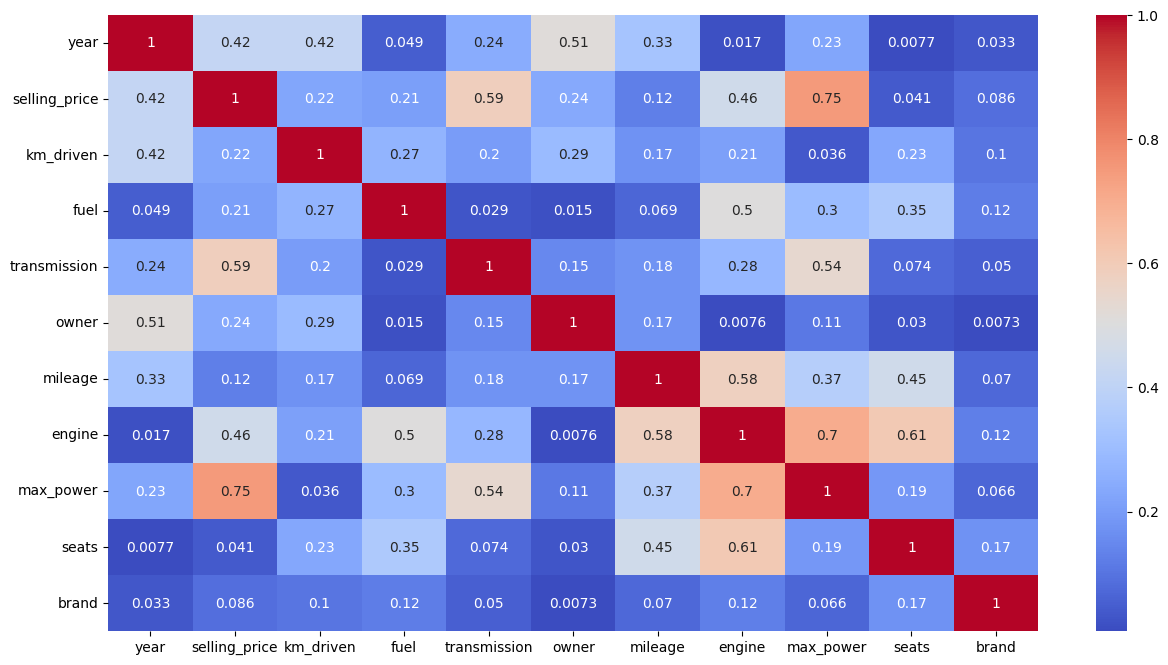

In [619]:
#Correlation matrix to see the correlation between the features
plt.figure(figsize = (15,8))
sns.heatmap(abs(df[selected_cols].corr(numeric_only=True)), annot=True, cmap="coolwarm")

In [620]:
# feature correlation more than equal or more than 40%
feauture_selection_heatmap = ['year', 'transmission', 'engine', 'max_power']

<Axes: xlabel='x', ylabel='y'>

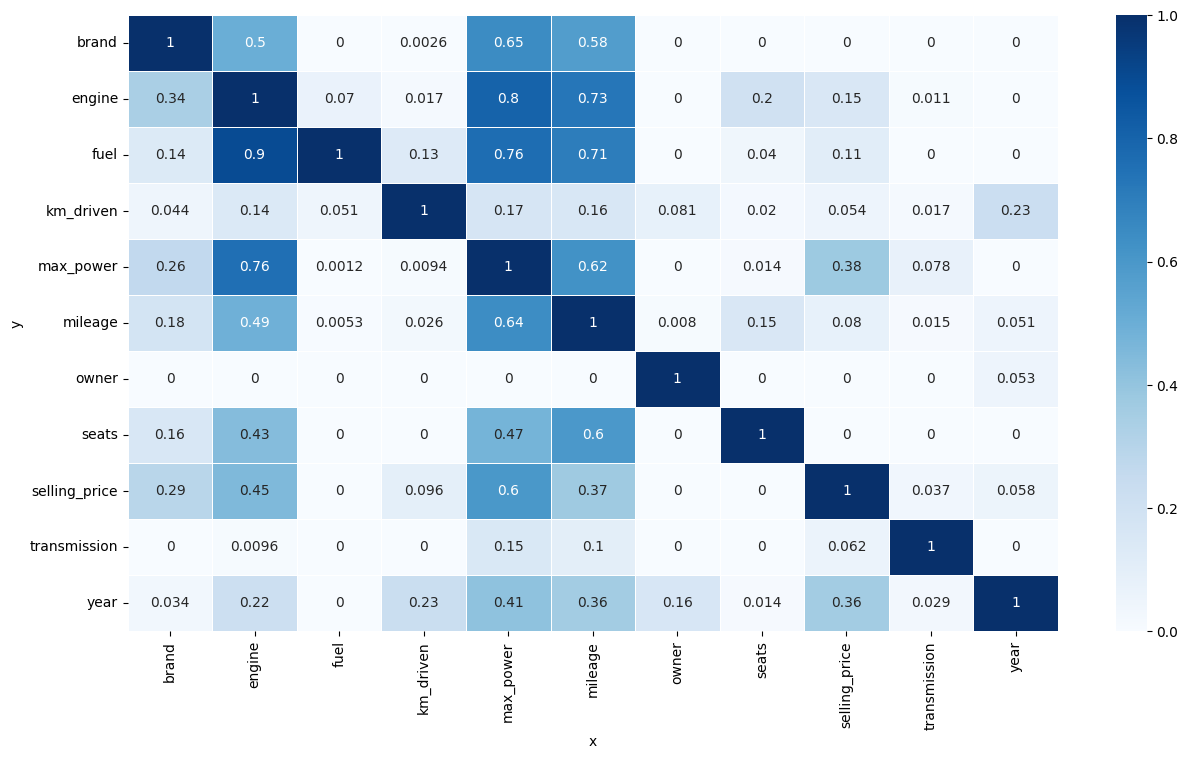

In [621]:
# Predictive power score of features using correlation values
import ppscore as pps

matrix_df = pps.matrix(df[selected_cols])[['x', 'y', 'ppscore']].pivot(columns='x', index='y', values='ppscore')

plt.figure(figsize = (15,8))
sns.heatmap(matrix_df, vmin=0, vmax=1, cmap="Blues", linewidths=0.5, annot=True)

In [622]:
# predicting power more than 10% after rounding to two decimal digits
feature_selection_list = ['brand','engine', 'km_driven', 'max_power', 'mileage', 'year']

feauture_selection_heatmap = ['year', 'transmission', 'engine', 'max_power']

# Combining feature for both graph
selected_features = ['year', 'brand', 'transmission', 'engine', 'km_driven', 'max_power', 'mileage']

selected_features_df = df[selected_features]

selected_features_df.head()


,year,brand,transmission,engine,km_driven,max_power,mileage
0,2014,20,1,1248.0,145500,74.00,23.40
1,2014,27,1,1498.0,120000,103.52,21.14
2,2006,10,1,1497.0,140000,78.00,17.70
3,2010,11,1,1396.0,127000,90.00,23.00
4,2007,20,1,1298.0,120000,88.20,16.10


<Axes: >

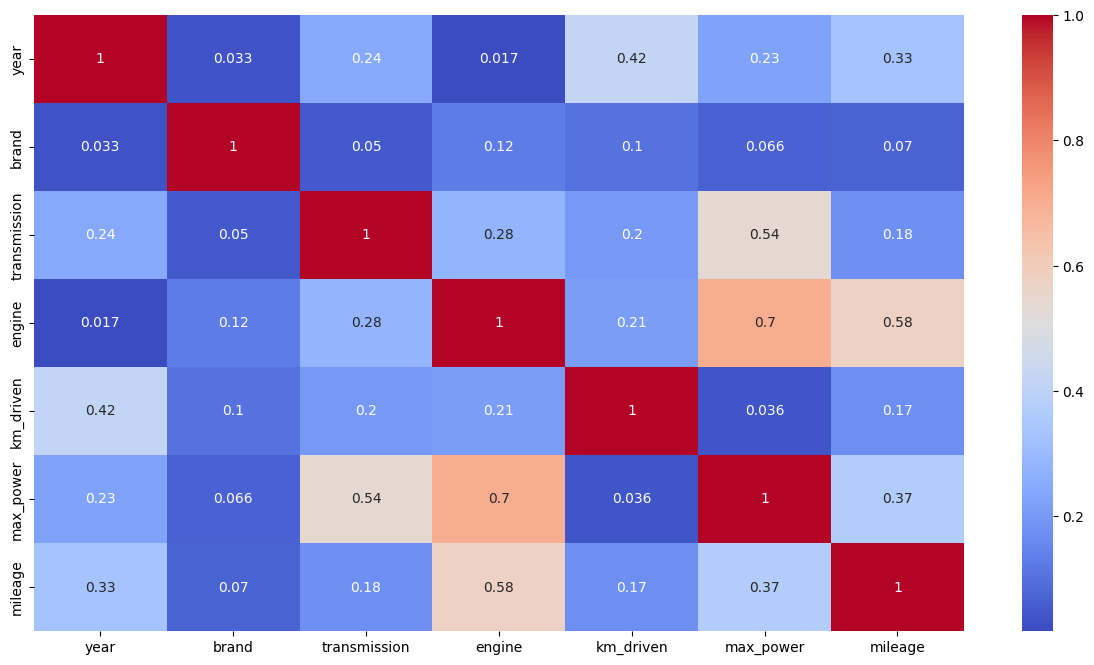

In [623]:
# since we have 7 features, checking if these features are correlated to each other if yes, removing correlated ones.
plt.figure(figsize = (15,8))
sns.heatmap(abs(selected_features_df.corr(numeric_only=True)), annot=True, cmap="coolwarm")


Since there's no strong corellation between any selected features, including all features in training 

# Data Processing

In [624]:
selected_features_df.head()

,year,brand,transmission,engine,km_driven,max_power,mileage
0,2014,20,1,1248.0,145500,74.00,23.40
1,2014,27,1,1498.0,120000,103.52,21.14
2,2006,10,1,1497.0,140000,78.00,17.70
3,2010,11,1,1396.0,127000,90.00,23.00
4,2007,20,1,1298.0,120000,88.20,16.10


In [625]:
selected_features_df.describe()

,year,brand,transmission,engine,km_driven,max_power,mileage
count,8028.000000,8028.000000,8028.000000,7814.000000,8.028000e+03,7820.000000,7814.000000
mean,2013.815521,18.004235,0.869706,1462.914640,6.977314e+04,91.819726,19.391962
std,4.030836,7.388504,0.336648,504.759742,5.664419e+04,35.804513,4.001972
min,1983.000000,0.000000,0.000000,624.000000,1.000000e+03,0.000000,0.000000
25%,2011.000000,11.000000,1.000000,1197.000000,3.500000e+04,68.850000,16.780000
50%,2015.000000,20.000000,1.000000,1248.000000,6.000000e+04,82.400000,19.300000
75%,2017.000000,20.000000,1.000000,1582.000000,9.800000e+04,102.000000,22.320000
max,2020.000000,31.000000,1.000000,3604.000000,2.360457e+06,400.000000,42.000000


In [626]:
# Check null values in selected features
selected_features_df.isnull().sum()

year              0
brand             0
transmission      0
engine          214
km_driven         0
max_power       208
mileage         214
dtype: int64

In [627]:
null_columns = selected_features_df.columns[selected_features_df.isnull().any()]
null_columns

Index(['engine', 'max_power', 'mileage'], dtype='object')

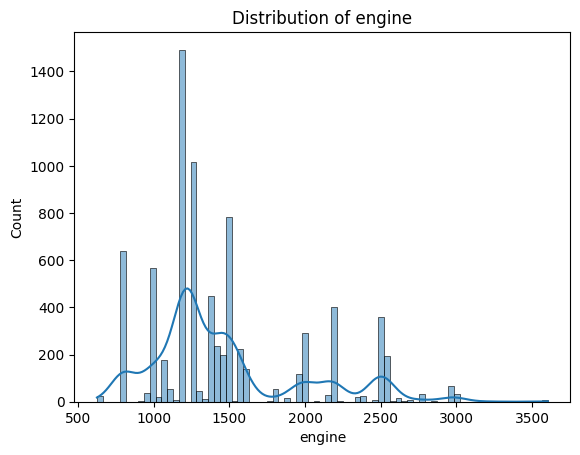

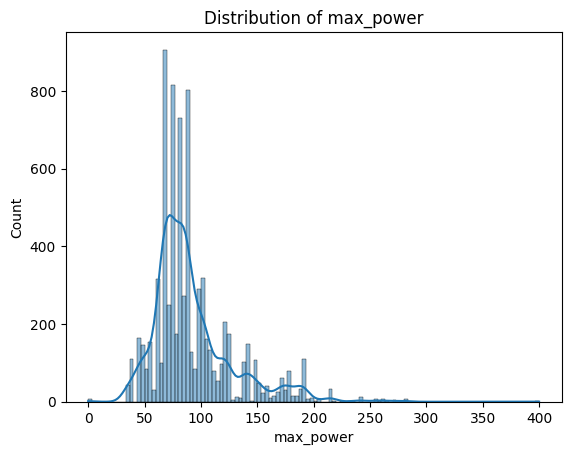

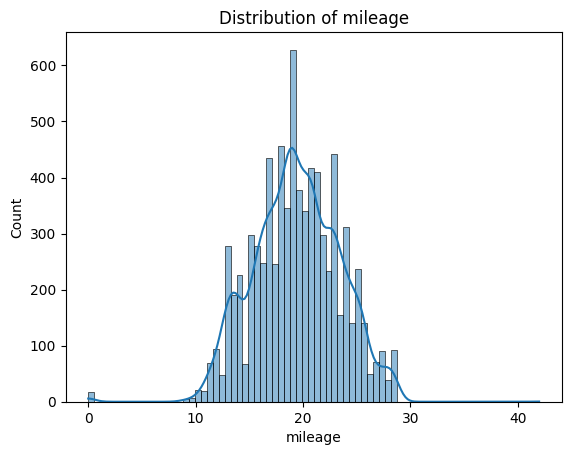

In [628]:
# Check nature of data for imputing
# Learning the distribution before scaling
for col in null_columns:
    sns.histplot(df, x=df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.show()

# Analysing Data

Let's tackle one column at a time

1. Distribution of engine

Engine data distribution is skewed. It looks like categorical. The best way is to fill null values with domain knowledge. From corelation plot, it's obvious that engine has strong correlation of 70% with `max_power`. 

#### Decision 1: Drop feature `engine` for 3 reasons

- 1. `engine` has null values
- 2. `max_power` is highly correlated and can be dropped.
- 3. we don't have domain knowledge

In [629]:
# Decision 1: drop engine since it has too many null values
selected_features_df = selected_features_df.drop(columns=['engine'], errors='ignore')

selected_features_df.head()

,year,brand,transmission,km_driven,max_power,mileage
0,2014,20,1,145500,74.00,23.40
1,2014,27,1,120000,103.52,21.14
2,2006,10,1,140000,78.00,17.70
3,2010,11,1,127000,90.00,23.00
4,2007,20,1,120000,88.20,16.10


2. Distribution of `max_power`

The distribution plot of `max_power` is somewhat normal with long tail. 

#### Decision 2: Apply log transformation to reduce long tail.


In [630]:
selected_features_df['max_power'].describe()

count    7820.000000
mean       91.819726
std        35.804513
min         0.000000
25%        68.850000
50%        82.400000
75%       102.000000
max       400.000000
Name: max_power, dtype: float64

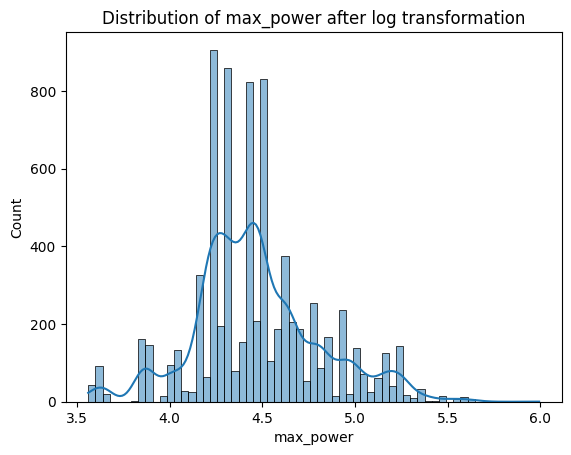

In [631]:
# Decision 2: apply log transformation to reduce long tail. Removing negative and zero values before log transformation
max_power_log = np.log1p(selected_features_df['max_power'][selected_features_df['max_power'] > 0])

# histplot after log transformation
sns.histplot(selected_features_df, x=max_power_log, kde=True)
plt.title(f'Distribution of max_power after log transformation')
plt.show()

In [632]:
# Since max_power looks more skewed after log transformation, checking skewness value
print("Skew value: " , max_power_log.skew())

Skew value:  0.39107951705149296


In [633]:
# Since skew value is less than 0.5, it can be considered as somewhat normal
# Keeping the log transformed value
selected_features_df['max_power'] = max_power_log

3. Distribution of mileage

The distribution plot is almost bell shaped, it's normal distribution, imputation will be done using mean value

#### Decision 3: `mileage` - imputed using mean value after splitting

In [634]:
selected_features_df.head()

,year,brand,transmission,km_driven,max_power,mileage
0,2014,20,1,145500,4.317488,23.40
1,2014,27,1,120000,4.649378,21.14
2,2006,10,1,140000,4.369448,17.70
3,2010,11,1,127000,4.510860,23.00
4,2007,20,1,120000,4.490881,16.10


In [635]:
selected_features_df['brand'].nunique()

32

#### Decision 4 : Drop `brand` eventhough it has PPS vlaue above 10% (~22%)


- 1. 32 categories and one hot encoding will explore the feature dataset If high cardinality: frequency encoding, target encoding (with CV), or HashingEncoder. Or drop if brand has no signal.
- 2. Lack of domain knowledge to categorize in bigger groups

In [636]:
# Decision 4: Drop `brand` eventhough it has PPS vlaue above 10% (~22%)
selected_features_df = selected_features_df.drop(columns=['brand'], errors='ignore')

selected_features_df.head()

,year,transmission,km_driven,max_power,mileage
0,2014,1,145500,4.317488,23.40
1,2014,1,120000,4.649378,21.14
2,2006,1,140000,4.369448,17.70
3,2010,1,127000,4.510860,23.00
4,2007,1,120000,4.490881,16.10


# Feature engineering on year

Option 1: Divide car into 2 groups - Old / New

Again we don't have domain knowledge, how to select the number of years to define the old car

Option 2: Add `car_age` 

Compute age = max_year - year (numeric). Optionally create boolean old = age > 5, it will be a coarse feature.
Computing age from Year.max() must be consistent between train and test. Prefer using a fixed reference (e.g., current year or dataset max_year computed on the full dataset before the split). Safer: age = current_year - year.

#### Decision 5: Replace `year` with age calculated using current_year - year
    

In [637]:
from datetime import date

selected_features_df['year'] = date.today().year - selected_features_df['year']

In [638]:
selected_features_df.isnull().sum()

year              0
transmission      0
km_driven         0
max_power       214
mileage         214
dtype: int64

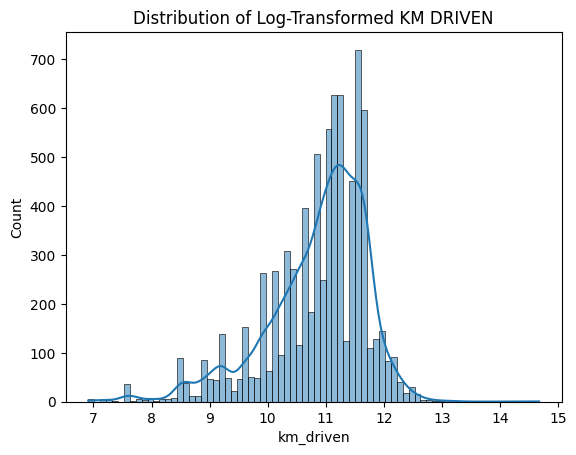

In [639]:
# Apply log transformation to reduce long tail effect
km_driven_log = np.log1p(df.km_driven)
sns.histplot(km_driven_log, kde=True)
plt.title('Distribution of Log-Transformed KM DRIVEN')
plt.show()

In [640]:
# replace km_driven with log transformed value
selected_features_df['km_driven'] = km_driven_log

# Feature Scaling

We know the nature of all feature values , we can start imputing. 

Scaling not required for transmission as it's value is binary (0/1)

#### Decision 6: Impute `max_power` & `mileage` with mean value

In [641]:
cols_to_impute_mean = ['max_power', 'mileage']
# features/independent variables
X = selected_features_df

# Target: use log of selling_price for numerical stability
y = np.log(df['selling_price'])

# quick check
print("X shape (rows, number of features):", selected_features_df.shape)
print("y shape: (rows)", y.shape)
print(X.head(), y.head())

X shape (rows, number of features): (8028, 5)
y shape: (rows) (8028,)
   year  transmission  km_driven  max_power  mileage
0    11             1  11.887938   4.317488    23.40
1    11             1  11.695255   4.649378    21.14
2    19             1  11.849405   4.369448    17.70
3    15             1  11.751950   4.510860    23.00
4    18             1  11.695255   4.490881    16.10 0    13.017003
1    12.821258
2    11.970350
3    12.323856
4    11.775290
Name: selling_price, dtype: float64


In [642]:
# Split data into train and test
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [643]:
# Impute null columns with mean for numerical columns with normal distribution
from sklearn.impute import SimpleImputer
mean_imputer_list = {}
for col in cols_to_impute_mean:
    imputer = SimpleImputer(strategy='mean')
    X_train[col] = imputer.fit_transform(X_train[[col]])
    X_test[col] = imputer.transform(X_test[[col]])
    mean_imputer_list[col] = imputer

mean_imputer_list

{'max_power': SimpleImputer(), 'mileage': SimpleImputer()}

In [644]:
# Check if nulls exists after imputation
assert (X_train.isnull().sum() == 0).all(), "Null values remain in X_train after imputation"
assert (X_test.isnull().sum() == 0).all(), "Null values remain in X_test after imputation"

In [645]:
# => Distribution for these features is almost normal, using Standardization technique for scaling
cols_to_standard_scaling = ['km_driven', 'max_power','mileage', 'year']

In [646]:
# Since it's nearly normally distibuted, using Standard scaling
from sklearn.preprocessing import StandardScaler

standard_scaler_list = []

for col in cols_to_standard_scaling:
    scaler = StandardScaler()  
    X_train[col] = scaler.fit_transform(X_train[[col]])
    X_test[col] = scaler.transform(X_test[[col]])
    standard_scaler_list.append((col, scaler))  # Store the scaler for future use

# standard_scaler_list contains the scalers for each column 
standard_scaler_list

[('km_driven', StandardScaler()),
 ('max_power', StandardScaler()),
 ('mileage', StandardScaler()),
 ('year', StandardScaler())]

In [647]:
# features value after scaling
cols_to_standard_scaling, X_train.head(), X_test.head()

(['km_driven', 'max_power', 'mileage', 'year'],
           year  transmission  km_driven  max_power   mileage
 2948 -0.539209             1   0.148799  -1.392342  1.458607
 2412  0.202184             1   0.162167  -1.736018  0.846119
 6210  1.190708             1   0.083576   0.000000  0.000000
 6171 -1.033471             1  -0.045519   1.683605 -0.449432
 4201  3.662018             1   0.744064  -0.689151 -1.155180,
           year  transmission  km_driven  max_power   mileage
 5867  0.696446             1  -0.451814   0.123139 -1.104770
 5957 -0.539209             1   0.852635   1.106098  0.072317
 3032 -0.292078             1   0.162167  -0.730274  0.284041
 6445 -0.044947             1   0.489874   0.664978 -0.094038
 318  -1.033471             1  -0.666026  -0.445594  1.163705)

In [648]:
X_train.describe(), X_test.describe()

(               year  transmission     km_driven     max_power       mileage
 count  6.422000e+03   6422.000000  6.422000e+03  6.422000e+03  6.422000e+03
 mean  -1.477070e-16      0.867798  1.020119e-15  7.158536e-16 -1.748143e-16
 std    1.000078e+00      0.338736  1.000078e+00  1.000078e+00  1.000078e+00
 min   -1.527733e+00      0.000000 -4.500762e+00 -2.664632e+00 -4.885560e+00
 25%   -7.863400e-01      1.000000 -4.518138e-01 -6.469190e-01 -6.510747e-01
 50%   -2.920779e-01      1.000000  1.621674e-01 -8.397138e-02  0.000000e+00
 75%    6.964462e-01      1.000000  7.440639e-01  4.867047e-01  6.772432e-01
 max    7.616115e+00      1.000000  4.345389e+00  3.453234e+00  2.272737e+00,
               year  transmission    km_driven    max_power      mileage
 count  1606.000000   1606.000000  1606.000000  1606.000000  1606.000000
 mean      0.003217      0.877335     0.000892    -0.000940     0.010881
 std       0.980562      0.328154     0.944916     0.999763     0.975562
 min      -1.5

# Model Selection

In [649]:
from sklearn.model_selection import KFold

class LinearRegression(object):

    number_of_kfold = 5
    
    #in this class, we add cross validation as well for some spicy code....
    kfold = KFold(n_splits=number_of_kfold)

    """
    Linear Regression model with gradient descent optimization and regularization.
    Supports batch, stochastic, and mini-batch gradient descent methods.
    """
    def __init__(self, regularization, lr=0.001, method='batch', 
                 init_method= 'xavier', use_momentum=True, momentum= 0.5, 
                 polynomial= True, degree=3,
                 num_epochs=500, batch_size=50, cv=kfold):
        """
        Initialize the LinearRegression model.

        Parameters:
        - regularization: Regularization method (e.g., L1, L2)
        - lr: Learning rate for gradient descent
        - method: Optimization method ('batch', 'sto' for stochastic, 'mini' for mini-batch)
        - init_method: Weight initialization method ('xavier' else 'zero') default is 'xavier' (newly added)
        - use_momentum: Use momentum in gradient descent (True or False) default is True (newly added)
        - momentum: Momentum coefficient (default is 0.5) (newly added)
        - polynomial: Whether to use polynomial feature transformation (default is True) (newly added)
        - degree: Degree of polynomial features
        - num_epochs: Number of training epochs
        - batch_size: Size of mini-batches (for 'mini' method)
        - cv: Cross-validation method (default is 3-fold cross-validation)
        """
        self.regularization = regularization
        self.lr         = lr
        self.method     = method
        self.init_method = init_method
        self.use_momentum = use_momentum
        self.momentum = momentum
        self.polynomial = polynomial
        self.degree = degree
        self.num_epochs = num_epochs
        self.batch_size = batch_size
        self.cv         = cv
        # prev_step will be initialized after theta is created so it matches shape
        self.prev_step  = None
        print(f"""Initialized LinearRegression with {type(self.regularization).__name__} regularization, 
              lr={self.lr}, 
              method={self.method}, 
              init_method={self.init_method}, 
              use_momentum={self.use_momentum},
              momentum={self.momentum},
              polynomial={self.polynomial},
              degree={self.degree},
              num_epochs={self.num_epochs}, 
              batch_size={self.batch_size},
              cv={self.cv.n_splits} folds.""") 
        
    def mse(self, ytrue, ypred):
        return ((ypred - ytrue) ** 2).sum() / ytrue.shape[0]
    
    def r2(self, ytrue, ypred):
        return 1 - ((ytrue - ypred) ** 2).sum() / ((ytrue - ytrue.mean()) ** 2).sum()
    
    def xavier_init(self, dataset):
        size = dataset.shape[0]
        #calculate the range for the weights
        random_weights = np.random.rand(dataset.shape[1])
        #scale them using lower and upper bounds
        lower, upper = -(1.0/np.sqrt(size)), 1.0/np.sqrt(size)
        scaled_weights = lower + random_weights * (upper - lower)
        return scaled_weights
    
    def fit(self, X_train, y_train):
        # store column names if pandas provided (for later feature importance)
        # self.columns = X_train.
        # Store column names first
        if hasattr(X_train, "columns"):
            self.columns = X_train.columns
        else:
            self.columns = [f"x{i}" for i in range(X_train.shape[1])]

        # Convert to numpy arrays
        X_train = np.array(X_train)
        y_train = np.array(y_train).ravel()  # flatten target

        # quick sanity checks
        if np.isnan(X_train).any():
            raise ValueError("NaN found in X_train - please impute or drop missing values before training")
        if np.isnan(y_train).any():
            raise ValueError("NaN found in y_train - please impute or drop missing values before training")

        #create a list of kfold scores
        self.kfold_scores = list()
        
        #reset val loss
        self.val_loss_old = np.inf

        #kfold.split in the sklearn.....
        #5 splits
        for fold, (train_idx, val_idx) in enumerate(self.cv.split(X_train)):
            
            X_cross_train = X_train[train_idx]
            y_cross_train = y_train[train_idx]
            X_cross_val   = X_train[val_idx]
            y_cross_val   = y_train[val_idx]

            if self.init_method == 'xavier':
                self.theta = self.xavier_init(X_cross_train)
            else:
                self.theta = np.zeros(X_cross_train.shape[1]) # zero initialization if not xavier
            
            # ensure momentum buffer matches theta shape
            if self.prev_step is None:
                self.prev_step = np.zeros_like(self.theta)
            
            #one epoch will exhaust the WHOLE training set
            with mlflow.start_run(run_name=f"Fold-{fold}", nested=True):
                
                params = {"method": self.method, "lr": self.lr, "reg": type(self).__name__}
                mlflow.log_params(params=params)
                
                for epoch in range(self.num_epochs):
                
                    #with replacement or no replacement
                    #with replacement means just randomize
                    #with no replacement means 0:50, 51:100, 101:150, ......300:323
                    #shuffle your index
                    perm = np.random.permutation(X_cross_train.shape[0])
                            
                    X_cross_train = X_cross_train[perm]
                    y_cross_train = y_cross_train[perm]
                    
                    if self.method == 'sto':
                        for batch_idx in range(X_cross_train.shape[0]):
                            # keep 2D shape for X and 1D shape for y (size 1) so downstream code is consistent
                            X_method_train = X_cross_train[batch_idx:batch_idx+1, :]
                            y_method_train = y_cross_train[batch_idx:batch_idx+1]
                            train_loss = self._train(X_method_train, y_method_train)
                    elif self.method == 'mini':
                        for batch_idx in range(0, X_cross_train.shape[0], self.batch_size):
                            #batch_idx = 0, 50, 100, 150
                            X_method_train = X_cross_train[batch_idx:batch_idx+self.batch_size, :]
                            y_method_train = y_cross_train[batch_idx:batch_idx+self.batch_size]
                            train_loss = self._train(X_method_train, y_method_train)
                    else:
                        X_method_train = X_cross_train
                        y_method_train = y_cross_train
                        train_loss = self._train(X_method_train, y_method_train)
                    # print(self.method, train_loss)
                    mlflow.log_metric(key="train_loss", value=train_loss, step=epoch)

                    yhat_val = self.predict(X_cross_val)
                    val_loss_new = self.mse(y_cross_val, yhat_val)
                    mlflow.log_metric(key="val_loss", value=val_loss_new, step=epoch)
                    
                    #early stopping
                    if np.allclose(val_loss_new, self.val_loss_old):
                        break
                    self.val_loss_old = val_loss_new
            
                self.kfold_scores.append(val_loss_new)
                print(f"Fold {fold}: {val_loss_new}")
            
                    
    def _train(self, X, y):
        # ensure proper array shapes
        X = np.asarray(X)
        y = np.asarray(y).ravel()

        yhat = self.predict(X)
        yhat = np.asarray(yhat).ravel()
        m    = X.shape[0]

        # gradient (shape: n_features,)
        residual = (yhat - y)
        grad = (X.T @ residual) / m
        if self.regularization:
            grad = grad + self.regularization.derivation(self.theta)

        if hasattr(self, 'use_momentum') and self.use_momentum:
            # compute step and apply momentum
            self.step = self.lr * grad
            self.theta = self.theta - self.step + self.momentum * self.prev_step
            self.prev_step = self.step
        else:
            self.theta = self.theta - self.lr * grad

        return self.mse(y, yhat)
    
    def predict(self, X):
        # coerce to 2D for matrix multiplication and return 1-D predictions
        X = np.asarray(X)
        if X.ndim == 1:
            X = X.reshape(1, -1)
        return (X @ self.theta).ravel()  #===>(m, n) @ (n, ) -> (m,)
    
    def _transform_features(self, X):
       X_poly = np.column_stack([X**i (self.degree)])
       return X_poly
    
    def predict_polynomial(self, X):
        if self.polynomial == True:
            X = self._transform_features(X) #if polynomial is true, then transform the features
        return X @ self.theta  # (m, n_poly) @ (n_poly, )
    
    def _coef(self):
        return self.theta[1:]  #remind that theta is (w0, w1, w2, w3, w4.....wn)
                               #w0 is the bias or the intercept
                               #w1....wn are the weights / coefficients / theta
    def _bias(self):
        return self.theta[0]
    

    def feature_importance(self, width=5, height=10):
        """
        Visualize the feature importance by creating a horizontal bar plot of coefficients.

        Parameters:
        - width: Width of the plot (default is 5)
        - height: Height of the plot (default is 10)

        This method creates a bar plot showing the importance of each feature (coefficient) in the linear regression model.
        It uses the model's coefficients and corresponding feature names to generate the plot. If the model hasn't been trained",
        """
    # Create a DataFrame with coefficients and feature names, if available
        if self.theta is not None and self.columns is not None:
            coefs = pd.DataFrame(data=self.theta, columns=['Coefficients'],index=self.columns) 
            coefs.plot(kind="barh", figsize=(width, height)) # Create a horizontal bar plot
            plt.title("Feature Importance") # Set the title of the plot
            plt.show()  # Display the plot
        else:
            print("Coefficients or feature names are not available to create the graph.")

Now we can create `Ridge`, `Lasso` and `Elastic` class that extends the `LinearRegression`, with added penalty.

In [650]:
class LassoPenalty:
    
    def __init__(self, l):
        self.l = l # lambda value
        
    def __call__(self, theta): #__call__ allows us to call class as method
        return self.l * np.sum(np.abs(theta))
        
    def derivation(self, theta):
        return self.l * np.sign(theta)
    
class RidgePenalty:
    
    def __init__(self, l):
        self.l = l
        
    def __call__(self, theta): #__call__ allows us to call class as method
        return self.l * np.sum(np.square(theta))
        
    def derivation(self, theta):
        return self.l * 2 * theta
    
class ElasticPenalty:
    
    def __init__(self, l = 0.1, l_ratio = 0.5):
        self.l = l 
        self.l_ratio = l_ratio

    def __call__(self, theta):  #__call__ allows us to call class as method
        l1_contribution = self.l_ratio * self.l * np.sum(np.abs(theta))
        l2_contribution = (1 - self.l_ratio) * self.l * 0.5 * np.sum(np.square(theta))
        return (l1_contribution + l2_contribution)

    def derivation(self, theta):
        l1_derivation = self.l * self.l_ratio * np.sign(theta)
        l2_derivation = self.l * (1 - self.l_ratio) * theta
        return (l1_derivation + l2_derivation)
    
class Lasso(LinearRegression):
    
    def __init__(self, method, lr, l, init_method= 'xavier', use_momentum=True, momentum= 0.5, polynomial= True, degree=3):
        self.regularization = LassoPenalty(l)
        super().__init__(self.regularization, lr, method, init_method, use_momentum, momentum, polynomial, degree)
        
class Ridge(LinearRegression):
    
    def __init__(self, method, lr, l, init_method= 'xavier', use_momentum=True, momentum= 0.5, polynomial= True, degree=3):
        self.regularization = RidgePenalty(l)
        super().__init__(self.regularization, lr, method, init_method, use_momentum, momentum, polynomial, degree)
        
class ElasticNet(LinearRegression):
    
    def __init__(self, method, lr, l, l_ratio=0.5, init_method= 'xavier', use_momentum=True, momentum= 0.5, polynomial= True, degree=3):
        self.regularization = ElasticPenalty(l, l_ratio)
        super().__init__(self.regularization, lr, method, init_method, use_momentum, momentum, polynomial, degree)



class Normal(LinearRegression):
    def __init__(self, method, lr, l, l_ratio=0.5, init_method= 'xavier', use_momentum=True, momentum= 0.5, polynomial= True, degree=3):
        self.regularization = None # No regularization
        super().__init__(self.regularization, lr, method, init_method, use_momentum, momentum, polynomial, degree)



## Experiment

In [651]:
#helper function for looping classnames
import sys

def str_to_class(classname):
    return getattr(sys.modules[__name__], classname)

In [652]:
# Training model: Fit and Predict 
regs = ["Ridge", "Lasso", "ElasticNet", "Normal"]

learning_rates = [0.01, 0.001, 0.0001]
coefficient = 0.1

gradient_descent = ['batch', 'sto', 'mini']

# not quite efficient but works for now
for reg in regs:
    for method in gradient_descent:
        for learning_rate in learning_rates:
            for init_method in ['xavier', 'zero']:
                for use_momentum in [True, False]:

                    params = {"method": method, "lr": learning_rate, "l": coefficient, "init_method": init_method, "use_momentum": use_momentum}
                    mlflow.start_run(run_name=f"method-{params['method']}-lr-{params['lr']}-reg-{reg}-l-{params['l']}-init_method-{params['init_method']}-momentum-{params['use_momentum']}", nested=True)
            
                    print("="*5, reg, "="*5)

                    # #######
                    type_of_regression = str_to_class(reg)    #Ridge, Lasso, ElasticNet
                    model = type_of_regression(**params)  
                    model.fit(X_train, y_train)
                    yhat = model.predict(X_test)
                    mse  = model.mse(y_test, yhat)
                    r2 = model.r2(y_test, yhat)

                    print("Test MSE: ", mse)
                    print("Test R2: ", r2)
                    mlflow.log_metric(key="test_mse", value=mse)
                    mlflow.log_metric(key="test_r2", value=r2)

                    signature = mlflow.models.infer_signature(X_train, model.predict(X_train))
                    mlflow.sklearn.log_model(model, artifact_path='model', signature=signature)
                    
                    mlflow.end_run()
                    #end of momentum loop
                # end of init method loop
            # end of learning rate loop
        # end of gradient descent method loop
    # end of regularization loop  

===== Ridge =====
Initialized LinearRegression with RidgePenalty regularization, 
              lr=0.01, 
              method=batch, 
              init_method=xavier, 
              use_momentum=True,
              momentum=0.5,
              polynomial=True,
              degree=3,
              num_epochs=500, 
              batch_size=50,
              cv=5 folds.
Fold 0: 26.168590121463193
🏃 View run Fold-0 at: http://localhost:9000/#/experiments/215259328580886044/runs/80af593559e8471d92f843e100edf04c
🧪 View experiment at: http://localhost:9000/#/experiments/215259328580886044
Fold 1: 29.325045814450547
🏃 View run Fold-1 at: http://localhost:9000/#/experiments/215259328580886044/runs/2761b3468bdf4c0d90ebff6cd59b4385
🧪 View experiment at: http://localhost:9000/#/experiments/215259328580886044
Fold 2: 28.68627048706446
🏃 View run Fold-2 at: http://localhost:9000/#/experiments/215259328580886044/runs/836a24674a0b4e81981d0fe103cf81a2
🧪 View experiment at: http://localhost:9000/#/exp

2025/11/23 17:46:47 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Fold 4: 28.42006106196778
🏃 View run Fold-4 at: http://localhost:9000/#/experiments/215259328580886044/runs/ed893dbe55254c1ba2c259593577b43e
🧪 View experiment at: http://localhost:9000/#/experiments/215259328580886044
Test MSE:  26.241979397311418
Test R2:  -35.84939513487679
🏃 View run method-batch-lr-0.01-reg-Ridge-l-0.1-init_method-xavier-momentum-True at: http://localhost:9000/#/experiments/215259328580886044/runs/20c27672b4c841329f8e345f4e84b52b
🧪 View experiment at: http://localhost:9000/#/experiments/215259328580886044
===== Ridge =====
Initialized LinearRegression with RidgePenalty regularization, 
              lr=0.01, 
              method=batch, 
              init_method=xavier, 
              use_momentum=False,
              momentum=0.5,
              polynomial=True,
              degree=3,
              num_epochs=500, 
              batch_size=50,
              cv=5 folds.
Fold 0: 21.915609186665357
🏃 View run Fold-0 at: http://localhost:9000/#/experiments/2152593285

2025/11/23 17:47:40 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Fold 4: 24.085676330864263
🏃 View run Fold-4 at: http://localhost:9000/#/experiments/215259328580886044/runs/ae2f156107224e009fba9311fd5893eb
🧪 View experiment at: http://localhost:9000/#/experiments/215259328580886044
Test MSE:  21.821350623134865
Test R2:  -29.64187953638016
🏃 View run method-batch-lr-0.01-reg-Ridge-l-0.1-init_method-xavier-momentum-False at: http://localhost:9000/#/experiments/215259328580886044/runs/49228845dfbb410a933dfb898121914d
🧪 View experiment at: http://localhost:9000/#/experiments/215259328580886044
===== Ridge =====
Initialized LinearRegression with RidgePenalty regularization, 
              lr=0.01, 
              method=batch, 
              init_method=zero, 
              use_momentum=True,
              momentum=0.5,
              polynomial=True,
              degree=3,
              num_epochs=500, 
              batch_size=50,
              cv=5 folds.
Fold 0: 26.17672256302216
🏃 View run Fold-0 at: http://localhost:9000/#/experiments/215259328580

...

Fold 4: 17.376342825862604
🏃 View run Fold-4 at: http://localhost:9000/#/experiments/215259328580886044/runs/0d26e889588747f7bcf9c2d4fdf5a116
🧪 View experiment at: http://localhost:9000/#/experiments/215259328580886044
Test MSE:  15.090250204448028
Test R2:  -20.189963761835422
🏃 View run method-mini-lr-0.0001-reg-Normal-l-0.1-init_method-xavier-momentum-False at: http://localhost:9000/#/experiments/215259328580886044/runs/a07757a4227a468c9f6807a181721325
🧪 View experiment at: http://localhost:9000/#/experiments/215259328580886044
===== Normal =====
Initialized LinearRegression with NoneType regularization, 
              lr=0.0001, 
              method=mini, 
              init_method=zero, 
              use_momentum=True,
              momentum=0.5,
              polynomial=True,
              degree=3,
              num_epochs=500, 
              batch_size=50,
              cv=5 folds.
Fold 0: 18.13867763600197
🏃 View run Fold-0 at: http://localhost:9000/#/experiments/21525932858

2025/11/23 19:50:46 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Fold 4: 20.109037945816958
🏃 View run Fold-4 at: http://localhost:9000/#/experiments/215259328580886044/runs/b1b0b08b36fd44e3bb42f6842331d480
🧪 View experiment at: http://localhost:9000/#/experiments/215259328580886044
Test MSE:  17.839506036551935
Test R2:  -24.050511510548336
🏃 View run method-mini-lr-0.0001-reg-Normal-l-0.1-init_method-zero-momentum-True at: http://localhost:9000/#/experiments/215259328580886044/runs/6a8d37bd30f148609be7531017152bf6
🧪 View experiment at: http://localhost:9000/#/experiments/215259328580886044
===== Normal =====
Initialized LinearRegression with NoneType regularization, 
              lr=0.0001, 
              method=mini, 
              init_method=zero, 
              use_momentum=False,
              momentum=0.5,
              polynomial=True,
              degree=3,
              num_epochs=500, 
              batch_size=50,
              cv=5 folds.
Fold 0: 15.893773151207998
🏃 View run Fold-0 at: http://localhost:9000/#/experiments/215259328580

2025/11/23 19:51:57 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Fold 4: 17.376217174946337
🏃 View run Fold-4 at: http://localhost:9000/#/experiments/215259328580886044/runs/57d813b3b7aa42a8b9295d0b1b5a29ea
🧪 View experiment at: http://localhost:9000/#/experiments/215259328580886044
Test MSE:  15.090263232235793
Test R2:  -20.189982055657385
🏃 View run method-mini-lr-0.0001-reg-Normal-l-0.1-init_method-zero-momentum-False at: http://localhost:9000/#/experiments/215259328580886044/runs/dd9e4ab80c9443528d63203a5077917e
🧪 View experiment at: http://localhost:9000/#/experiments/215259328580886044


## Group Workshop - Check your understandings

| | Egg price | Gold price    | Oil price   | GDP   | $\hat{y}$ |  $(\hat{y} - y)^2$ |
|---:|:------ |:-----------   |:------      |:------|:------    |  :------           |    
| 1  | 3      | 100           | 4           | 21    | 28        |  49                |
| 2  | 4      | 500           | 7           | 43    | 79        |  1296              |
| 3  | 5      | 200           | 6           | 56    | 48        |  64                |
| 4  | 6      | 300           | 8           | 21    | 66        |  2025              |
| 5  | 7      | 400           | 2           | 44    | 60        |  256               |

Note:  this table is filled with given weight of [2, 0.1, 3].

Answer the following questions:

Instruction:  Gather in your group.  Will randomly pick groups to present.

1.  Explain regularization in your own words.
2.  For `LassoPenalty`, show by hand why the derivation is `self.l * np.sign(theta)`
3.  For `RidgePenalty`, show by hand why the derivation is `self.l * 2 * theta`
4.  Using mini-batch gradient descent based on $(\mathbf{x}^{(2)}, \mathbf{x}^{(4)}, \mathbf{x}^{(5)})$, and using **Ridge regression**, what is $J(\theta)$?  Assume $\lambda = 0.1$
5.  Continued from above, what is $\displaystyle \frac{\partial J}{\partial \theta_2}$
6.  Continued from above, what is $\displaystyle \frac{\partial J}{\partial \theta}$
7.  What would be the new theta?
8.  Performed 4,5,6 with **Lasso Regression**.  Assume $\lambda = 0.1$
9.  What does `LinearRegression` inside `Ridge(LinearRegression)` mean?
10. What does `str_to_class` function do?
11. Based on everything you have done in this workshop, what do you think is a good way to decide when to use Ridge, Lasso, or Elastic regression.

## Learnings

1. Fold was returning INF always with 0.001 (learning rate). When printed training loss, it was quite high and increasing. Reducing the learning rate, helped to converge.
2. TODO: Add MSE for each fold 
